In [ ]:
#NAHEEM'S CODE

In [6]:
from pickle import FALSE

from metloom.pointdata import SnotelPointData
import geopandas as gpd
import os
import rioxarray as rxr
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import re
import xarray as xr
from scipy.stats import iqr

In [3]:
##Create a dictionary of snow depth rasters where the keyword is the date and the item is the filepath

sd_dir = 'C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/SNEX_MCS_Lidar/SD'
dir_25 = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"
raster_dict = {}
date_pattern = re.compile(r'\d{8}')
for root, dirs, files in os.walk(sd_dir):
    for filename in files:
        if date_pattern.search(filename):
            full_path = os.path.join(root, filename)
            split = filename.split('_')
            name = split[3]
            raster_dict[name] = os.path.abspath(full_path)

for root, dirs, files in os.walk(dir_25):
    for filename in files:
        if "MCS_clip" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict[name] = os.path.abspath(full_path) 
        
print(raster_dict)

{'20220217': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20220217_SD_V01.0.tif', '20220317': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20220317_SD_V01.0.tif', '20220407': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20220407_SD_V01.0.tif', '20221208': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20221208_SD_V01.0.tif', '20230209': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20230209_SD_V01.0.tif', '20230316': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20230316_SD_V01.0.tif', '20230405': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20230405_SD_V01.0.tif', '20231113': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_20231113_SD_V01.0.tif', '20231228': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\SNEX_MCS_Lidar\\SD\\SNEX_MCS_Lidar_202312

In [4]:
# #Get MCS point
pt = SnotelPointData("637:ID:SNTL", "MCS")
# request the data
df = pt.get_daily_data(datetime(2019, 10, 1), datetime(2026, 3, 30),
                                    [pt.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
df['SNOWDEPTH (m)'] = df['SNOWDEPTH'] * 0.0254
df.index = pd.to_datetime(df.index)

# Add the 'Date (MM-DD)' column
df['Date (MM-DD)'] = df.index.strftime('%m-%d')


df['WY'] = df.index.year + (df.index.month > 9).astype(int)

# Now, format the index to a string at the end
df.index = df.index.strftime('%Y-%m-%d')

In [16]:
## create a dataframe from the dictionary and make the date (keyword) a datetime object
sds = pd.DataFrame(raster_dict.items(), columns=['Filename', 'Filepath'])
sds['Date'] = pd.to_datetime(sds['Filename'], format='%Y%m%d')
sds['Date'] = sds['Date'].dt.strftime('%Y-%m-%d')

sds.set_index('Date', inplace=True)
sds = pd.concat([df, sds], axis=1, join='inner')


lidar_mean = []
lidar_std = []
lidar_median = []

lidar_filtered_mean = []
lidar_filtered_std = []
lidar_filtered_median = []
lidar_filtered_iqr = []
lidar_filtered_qd = []


for filename, raster in raster_dict.items():
        sd = rxr.open_rasterio(raster, masked = True)   
        date = pd.to_datetime(filename, format='%Y%m%d')
        lidar_mean.append(round(sd.mean().item(), 2))
        lidar_std.append(round(sd.std().item(), 2))
        lidar_median.append(round(sd.median().item(), 2))

        sd.values[sd.values < 0] = 0
        threshold = sd.mean() + 5 * sd.std() 
        sdf = sd.where(sd < threshold)
        iqr_value = iqr(sdf.values.flatten(), nan_policy='omit')
        quartile_deviation = iqr_value / 2
        # 
        lidar_filtered_mean.append(round(sdf.mean().item(), 2))
        lidar_filtered_std.append(round(sdf.std().item(), 2))
        lidar_filtered_median.append(round(sdf.median().item(), 2))
        lidar_filtered_iqr.append(round(iqr_value, 2))
        lidar_filtered_qd.append(round(quartile_deviation, 2))
        
    #add the lidar mean and std to the snotel dataframe
sds['LiDAR Mean (m)'] = lidar_mean
sds['LiDAR Std (m)'] = lidar_std
sds['Mean Difference (m)'] = sds['SNOWDEPTH (m)'] - sds['LiDAR Mean (m)']
sds['LiDAR Median (m)'] = lidar_median
sds['LiDAR filtered Mean (m)'] = lidar_filtered_mean
sds['LiDAR filtered Std (m)'] = lidar_filtered_std
sds['LiDAR filtered Median (m)'] = lidar_filtered_median
sds['LiDAR filtered IQR (m)'] = lidar_filtered_iqr
sds['LiDAR filtered QD (m)'] = lidar_filtered_qd



In [18]:
sds.to_csv("snotel_data_lidar.csv") # save the data to a csv file


In [19]:
sds_df = pd.read_csv("snotel_data_lidar.csv", index_col=0)


In [20]:
sds_df

,site,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m),Date (MM-DD),WY,Filename,Filepath,LiDAR Mean (m),LiDAR Std (m),Mean Difference (m),LiDAR Median (m),LiDAR filtered Mean (m),LiDAR filtered Std (m),LiDAR filtered Median (m),LiDAR filtered IQR (m),LiDAR filtered QD (m)
2022-02-17,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),55.0,in,NRCS,1.3970,02-17,2022,20220217,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,1.32,0.46,0.0770,1.33,1.32,0.46,1.33,0.65,0.32
2022-03-17,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),53.0,in,NRCS,1.3462,03-17,2022,20220317,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,1.18,0.52,0.1662,1.18,1.18,0.51,1.18,0.75,0.38
2022-04-07,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),39.0,in,NRCS,0.9906,04-07,2022,20220407,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,0.94,0.63,0.0506,0.92,0.95,0.62,0.92,1.05,0.53
2022-12-08,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),38.0,in,NRCS,0.9652,12-08,2023,20221208,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,0.94,0.32,0.0252,0.97,0.94,0.31,0.97,0.44,0.22
2023-02-09,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),65.0,in,NRCS,1.6510,02-09,2023,20230209,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,1.63,0.51,0.0210,1.67,1.63,0.50,1.67,0.73,0.36
2023-03-16,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),92.0,in,NRCS,2.3368,03-16,2023,20230316,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,2.46,0.74,-0.1232,2.56,2.46,0.74,2.56,1.10,0.55
2023-04-05,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),107.0,in,NRCS,2.7178,04-05,2023,20230405,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,2.71,0.86,0.0078,2.78,2.70,0.70,2.78,0.97,0.49
2023-11-13,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),1.0,in,NRCS,0.0254,11-13,2024,20231113,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,0.23,0.22,-0.2046,0.24,0.24,0.18,0.24,0.25,0.13
2023-12-28,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),19.0,in,NRCS,0.4826,12-28,2024,20231228,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,0.63,0.35,-0.1474,0.65,0.63,0.31,0.65,0.49,0.24
2024-01-15,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),46.0,in,NRCS,1.1684,01-15,2024,20240115,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\SNEX_MCS_L...,1.11,0.36,0.0584,1.15,1.11,0.35,1.15,0.48,0.24


In [83]:
sds_df.index = pd.to_datetime(sds_df.index, format='%Y-%m-%d')

for index, row in sds_df.iterrows():
    year = index.year
    month = index.month
    
    if month > 9:
        plot_year = str(year + 1)
    else:
        plot_year = str(year)

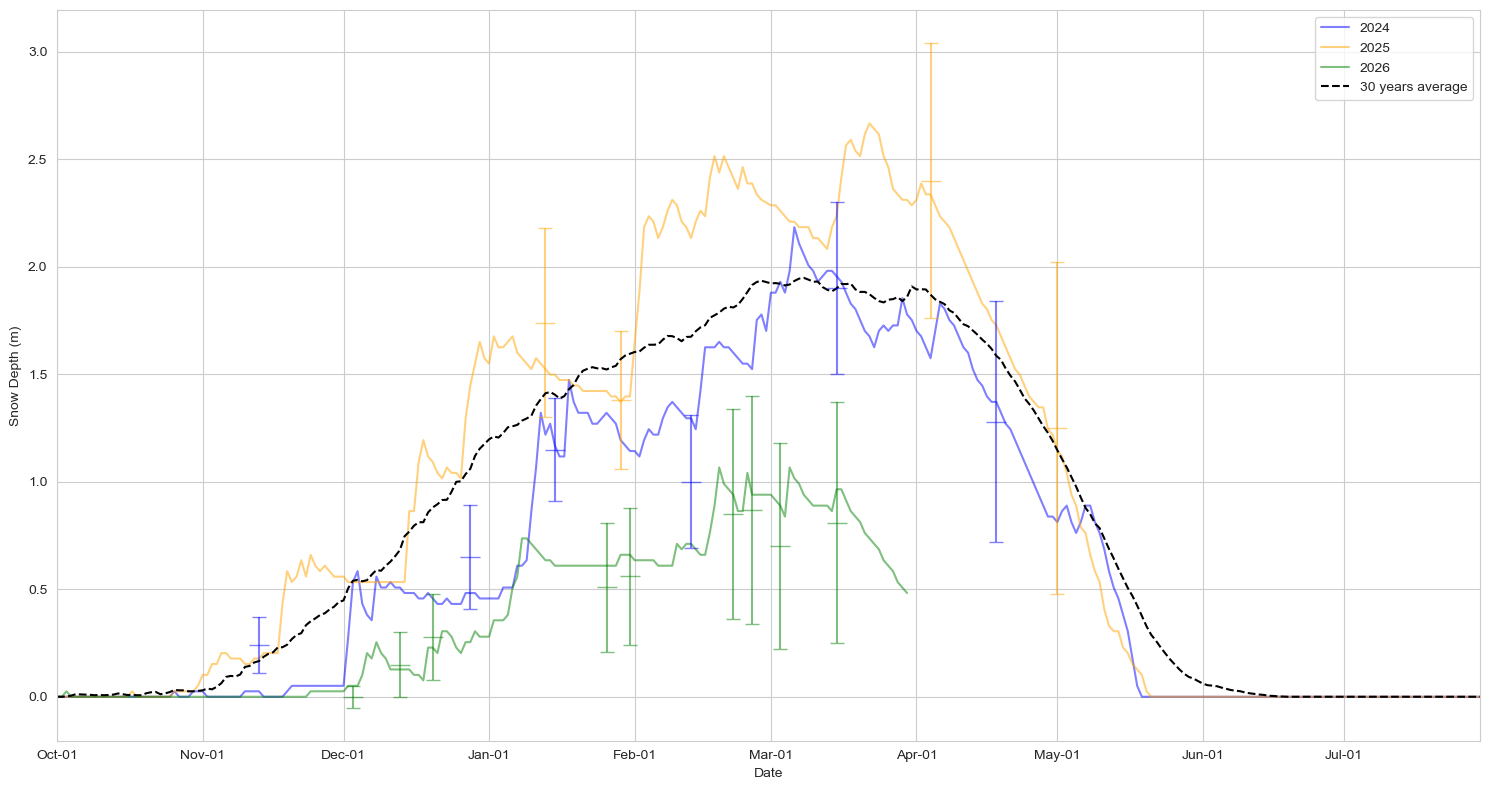

In [21]:
import matplotlib.colors as mcolors
pt = SnotelPointData("637:ID:SNTL", "MCS")

start_year  = 2024
end_year = 2026

fig, ax = plt.subplots(figsize=(15, 8))
colors = {start_year: 'blue', start_year + 1: 'orange', start_year + 2: 'green', start_year + 3: 'red', start_year + 4: 'purple'}

for i in range(start_year-1, end_year):
        record = df[str(i) + '-10-01':str(i+1) + '-09-30']
        record.index = pd.to_datetime(record.index)
        record.index = record.index.strftime('%m-%d') #convert the datetime index to MM-DD so I can plot all the years
        ax.plot(record.index, record['SNOWDEPTH (m)'], label = i+1, color = colors[i+1], alpha = 0.5)

sds_df.index = pd.to_datetime(sds_df.index, format='%Y-%m-%d')
for index, row in sds_df.iterrows():
    # split into month/day/year like your string logic
    date_yy = index.year
    date_mm = index.month

    # water year shift (same logic as your raster loop)
    if date_mm > 9:
        date_yy = date_yy + 1
    if date_yy >= start_year and date_yy <= end_year:
        date_mm_dd = index.strftime('%m-%d')
    
        ax.errorbar(
            x=date_mm_dd,
            y=row['LiDAR filtered Median (m)'],
            yerr=row['LiDAR filtered QD (m)'],
            marker='_',
            markersize=15,
            capsize=5,
            color=colors[date_yy],
            alpha = 0.5
        )
    # 
    # for filename, raster in raster_dict.items():
    #         sd = rxr.open_rasterio(raster, masked = True)   
    #         date = pd.to_datetime(filename, format='%Y%m%d')
    #         lidar_mean.append(round(sd.mean().item(), 2))
    #         lidar_std.append(round(sd.std().item(), 2))
    #         lidar_median.append(round(sd.median().item(), 2))
    
            
        #add the lidar mean and std to the snotel dataframe
    # sds['LiDAR Mean (m)'] = lidar_mean
    # sds['LiDAR Std (m)'] = lidar_std
    # sds['Mean Difference (m)'] = sds['SNOWDEPTH (m)'] - sds['LiDAR Mean (m)']
    # sds['LiDAR Median (m)'] = lidar_median



data_DDD = pt.get_daily_data(datetime(1993, 10, 1), datetime(2026, 3, 30),
                                       [pt.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
data_DDD['SNOWDEPTH (m)'] = data_DDD['SNOWDEPTH'] * 0.0254 #convert to meters
data_DDD.reset_index(inplace=True)
data_DDD['datetime'] = pd.to_datetime(data_DDD['datetime'])
data_DDD['day_of_year'] = data_DDD['datetime'].dt.dayofyear #add a new column (day_of_year) to the dataframe
data_DDD['year'] = data_DDD['datetime'].dt.year #add a new column (year) to the dataframe
daily_avg_snowdepth = data_DDD.groupby('day_of_year')['SNOWDEPTH (m)'].mean() #calculate the daily average snowdepth
daily_avg_snowdepth = daily_avg_snowdepth.reset_index() #reset the index
daily_avg_snowdepth['MM-DD'] = pd.to_datetime(daily_avg_snowdepth['day_of_year'], format='%j').dt.strftime('%m-%d') #add a new column (MM-DD) to the dataframe
daily_avg_snowdepth.set_index('MM-DD', inplace=True) #set the index to the YYYY-MM-DD column
#remove the last two rows (There is repetition of 01:01)
daily_avg_snowdepth = daily_avg_snowdepth[:-2]
#break the dataframe to two. Onw with records starting from 10-01 to 12-31 and the other from 01-01 to 09-30. Then combine them
daily_avg_snowdepth1 = daily_avg_snowdepth['10-01':'12-31']
daily_avg_snowdepth2 = daily_avg_snowdepth['01-01':'09-30']
daily_avg_snowdepth = pd.concat([daily_avg_snowdepth1, daily_avg_snowdepth2])
ax.plot(daily_avg_snowdepth.index, daily_avg_snowdepth['SNOWDEPTH (m)'], label='30 years average', linestyle='dashed', color='black')

        
    # Create major ticks for the first day of each month and minor ticks for the middle (day 15) of each month
major_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-01')]
minor_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-15')]
# Define a dictionary to map month numbers to their abbreviated names
month_map = {
    '10': 'Oct',
    '11': 'Nov',
    '12': 'Dec',
    '01': 'Jan',
    '02': 'Feb',
    '03': 'Mar',
    '04': 'Apr',
    '05': 'May',
    '06': 'Jun',
    '07': 'Jul',
    '08': 'Aug',
    '09': 'Sep'
}

# Create a new label format for the x-axis
new_labels = [month_map[date.split('-')[0]] + '-' + date.split('-')[1] for date in major_ticks]

# Set the major and minor ticks for the x-axis
plt.xticks(ticks = major_ticks, labels = new_labels)
plt.gca().set_xticks(minor_ticks, minor=True)

# # Display grid for both major and minor ticks
# plt.grid(which='both')
# plt.grid(which='both', alpha=0.2)

#set the xlimt
ax.set_xlim('10-01', '07-30')
# Add a legend
ax.legend()
#set axis label
ax.set_ylabel('Snow Depth (m)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()



In [ ]:
dates = df.index.get_level_values('datetime')
month = dates.month
mask = ((month >= 10) | (month <= 5))
df_filtered = df.loc[mask]
df_filtered.head()
df_filtered.to_csv("filtered_SNOTEL.csv")

In [ ]:
dates = df_filtered.index.get_level_values('datetime')
snowdepth = df_filtered['SNOWDEPTH (m)']

In [ ]:
LiDAR_dates = [
    '2020-02-09', '2021-03-15',  # added
    '2022-02-17', '2022-03-17', '2022-04-07',
    '2022-12-08', '2023-02-09', '2023-03-16',
    '2023-04-05', '2023-11-13', '2023-12-28',  # fixed 12-38 → 12-28
    '2024-01-15', '2024-02-13', '2024-03-15',
    '2024-04-28', '2025-01-25', '2025-01-29',
    '2025-04-04', '2025-05-01'
]

LiDAR_dates = pd.to_datetime(LiDAR_dates)

In [ ]:
    # Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-', label='Snow Depth')

for i, d in enumerate(LiDAR_dates):
        plt.axvline(
        d,
        color='red',
        linestyle='--',
        linewidth=1,
        label='LiDAR Survey' if i == 0 else None
    )

plt.xlabel('Date')
plt.ylabel('SNOWDEPTH (m)')
plt.title('Mores Creek SNOTEL')
plt.grid(True)
plt.legend()

# Optional: limit x-axis to 5 labels
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

plt.show()


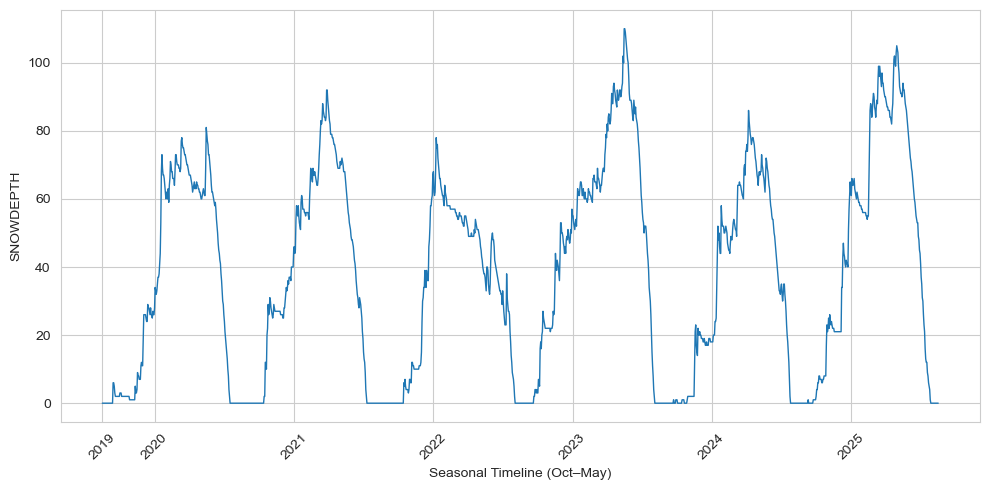

In [7]:
path = 'filtered_SNOTEL.csv'
df = pd.read_csv(path)
df=df.assign(datetime = pd.to_datetime(df.datetime))
df = df[df['datetime'].dt.month.isin([10,11,12,1,2,3,4,5])]
df = df.sort_values('datetime').reset_index(drop=True)

##Do same for LiDAR dates

# Create a pseudo x-axis that skips summer months
pseudo_x = []
prev_date = None
offset = 0
for d in df['datetime']:
    if prev_date is not None and (d - prev_date).days > 120:  # gap > ~4 months
        offset += 120  # skip the summer
    pseudo_x.append((d - df['datetime'].iloc[0]).days - offset)
    prev_date = d
df['pseudo_x'] = pseudo_x
# Determine where each season (year) starts
year_starts = df.groupby(df['datetime'].dt.year)['pseudo_x'].min()
# Plot


plt.figure(figsize=(10,5))
plt.plot(df['pseudo_x'], df['SNOWDEPTH'], lw=1)
plt.xlabel("Seasonal Timeline (Oct–May)")
plt.ylabel("SNOWDEPTH")

# Label each year’s start on the x-axis
plt.xticks(year_starts, year_starts.index, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##'2022-12-08', '2023-02-09', '2023-03-16', 2023-11-13', '2023-12-28',  # fixed 12-38 → 12-28'2024-01-15', '2024-02-13', '2024-03-15', '2024-04-28',

dates = WY2023.index.get_level_values('datetime')
snowdepth = WY2023['SNOWDEPTH (m)']

Wy23 = fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 23 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

# Add vertical lines, label only once
vlines = [pd.Timestamp("2022-12-08"), pd.Timestamp("2023-02-09"), pd.Timestamp("2023-03-16"), pd.Timestamp("2023-04-15")]
for i, dt in enumerate(vlines):
    if i == 0:
        ax.axvline(dt, color="red", linestyle="--", linewidth=1, label='LiDAR')
    else:
        ax.axvline(dt, color="red", linestyle="--", linewidth=1)

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.show()


In [ ]:
dates = df.index.get_level_values('datetime')
start = pd.Timestamp('2023-10-01 08:00:00+00:00')
end   = pd.Timestamp('2024-05-30 08:00:00+00:00')

mask = (dates >= start) & (dates <= end)

WY2024 = df.loc[mask]

WY2024

In [99]:
dates = WY2024.index.get_level_values('datetime')
snowdepth = WY2024['SNOWDEPTH (m)']

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 24 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

vlines = [
    pd.Timestamp("2023-12-28"),
    pd.Timestamp("2024-01-15"),
    pd.Timestamp("2024-02-13"),
    pd.Timestamp("2024-03-15"),
    pd.Timestamp("2024-04-28"),
]

for i, dt in enumerate(vlines):
    ax.axvline(
        dt,
        color="red",
        linestyle="--",
        linewidth=1,
        label="LiDAR" if i == 0 else None,
    )

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.tight_layout()
plt.show()


NameError: name 'WY2024' is not defined